# European Inflation Analysis

This project analyzes inflation trends in Europe using Eurostat data.

In [12]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt

In [3]:
conn = psycopg2.connect(
    host = "localhost",
    dbname = "financial_db",
    user = "postgres",
    password = "postgre123" 
)

query = "SELECT * FROM inflation_eu"
df = pd.read_sql(query,conn)

df.head()

C:\Users\john-\AppData\Local\Temp\ipykernel_4260\3075269043.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


,time,valeur
0,1996-01,80.70
1,1996-02,80.78
2,1996-03,80.87
3,1996-04,81.03
4,1996-05,81.11


In [ ]:
#Nettoyage et préparation
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time")
df = df.reset_index(drop = True)

df.head()

,time,valeur
0,1996-01-01,80.70
1,1996-01-01,80.70
2,1996-01-01,65.25
3,1996-01-01,80.70
4,1996-01-01,99.40


In [ ]:
#Inflation mensuelle (variation %)

df["inflation_mom"] = df["valeur"].pct_change()*100

In [11]:
df["inflation_smooth"] = df["valeur"].rolling(window=12).mean()

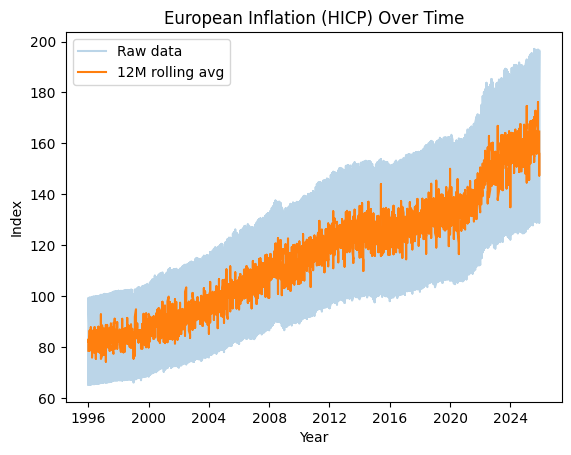

In [13]:
plt.figure()

plt.plot(df["time"], df["valeur"], alpha=0.3, label="Raw data")
plt.plot(df["time"], df["inflation_smooth"], label = "12M rolling avg")

plt.title("European Inflation (HICP) Over Time")
plt.xlabel("Year")
plt.ylabel("Index")
plt.legend()

plt.show()

## Key Insights

- Inflation steadily increased from 1996 to 2008
- Stability period between 2010-2019
- Sharp increase after 2021 (post-COVID + energy crisis)